# Building Neuro-AI Foundation Models with TorchBrain

*A hands-on tutorial on decoding behavior with TorchBrain (Janelia NeuroDataReHack).*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AlexandreAndr/janelia_ibl_bwm_talk/blob/main/wheel_speed_minimal_example.ipynb)

This tutorial walks you through a minimal training pipeline for **decoding
behavior** from spiking activity recorded in the **mouse brain with
Neuropixels probes**, using a single session of the IBL Brain-Wide Map. Each
session records several behavioral signals on a shared clock (wheel motion,
whisker motion energy, and paw positions/speeds), any of which can be a
decoding target.

<!-- TODO: check how many Neuropixels probes were inserted for this session -->

As a concrete, end-to-end example we decode **wheel speed** (a 1D continuous
signal sampled at 50 Hz). Treat it as an interactive starting point: the
**Hands On** section lets you swap in another behavioral covariate as the
decoding target, and can be extended further using the composable transforms
shown in the appendix.

The data comes from the IBL Brain-Wide Map:

[📄 Nature paper](https://www.nature.com/articles/s41586-025-09235-0){.btn .btn-outline-primary .btn-sm target="_blank"}
[🐍 ONE API](https://int-brain-lab.github.io/ONE/){.btn .btn-outline-primary .btn-sm target="_blank"}
[🧠 Interactive viz](https://viz.internationalbrainlab.org){.btn .btn-outline-primary .btn-sm target="_blank"}

By working through this tutorial, you will learn how to:

1. Build a custom `Dataset` on top of a `brainsets` recording, so any
   pre-processed session becomes trainable with a few lines of code.
2. Sample fixed-length trials around a decision-making task using
   `TrialSampler`, the standard pattern for turning a continuous recording
   into training examples.
3. Train and compare three small decoders (a linear readout, a bidirectional
   GRU, and a dilated TCN) on the same data pipeline, so you can see how
   architecture choice alone affects decoding performance.


## Setup

Neuroscience datasets are usually distributed through a lab- or
consortium-specific API, here the IBL's own **ONE API**. `brainsets` is a
pipeline that wraps around that native access pattern: it downloads the raw
session and converts it into the standardized HDF5 format that `torch-brain`
datasets expect. The pipeline used for a given dataset can be one shared by
[the community](https://github.com/neuro-galaxy/torch_brain/tree/main/torch_brain/pipeline/brainsets-pipelines),
or your own local, private one, kept outside that shared collection because
it's just an example, processes a private dataset, applies custom
processing, or is still in development.

This tutorial's own pipeline,
[`ibl_brain_wide_map_2025`](https://github.com/AlexandreAndr/janelia_ibl_bwm_talk/tree/main/ibl_brain_wide_map_2025),
falls in that latter category: a plain-Python `brainsets` pipeline kept
alongside this notebook as a worked example of the real flow, for anyone
curious how a raw IBL session gets turned into the standardized HDF5 format.
Running it downloads/processes ~5.5 GB of
raw data into a ~1.8 GB HDF5 file. For this tutorial we skip that step: the
cells below instead fetch the single, already-processed session straight
from the Hugging Face Hub (public, no login required), so you can get
started in seconds. See this folder's `README.md` for more details.


**If running in Colab:** install this notebook's pinned dependencies
that aren't already preinstalled.


In [1]:
# Running in Google Colab: install this notebook's pinned deps first. Colab
# starts from a blank runtime, but already has torch, scikit-learn, and
# matplotlib preinstalled, so only the packages it lacks need fetching; the
# session data itself is fetched separately from Hugging Face Hub below, so
# no repo checkout is required.
import os
import subprocess
import sys

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Keep this list in sync with requirements.txt.
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "torch-brain==0.2.0",
            "tqdm",
            "huggingface_hub",
            "bokeh",
        ],
        check=True,
    )

Pick the local paths and the single session (`RECORDING_ID`) this
tutorial decodes.

In [2]:
# This folder's own path, used to locate the local data dir regardless of cwd.
_HERE = (
    os.path.dirname(os.path.abspath(__file__))
    if "__file__" in globals()
    else os.getcwd()
)

# Which eval session to decode; the h5 lands under DATA_ROOT/DATASET_DIRNAME.
DATA_ROOT = os.path.join(_HERE, "processed")
DATASET_DIRNAME = "ibl_brain_wide_map_2025"
RECORDING_ID = "0802ced5-33a3-405e-8336-b65ebc5cb07c"

Download the pre-processed session from the Hugging Face Hub, skipping
the download if it's already on disk.

In [3]:
# Fetch the pre-processed session (~1.9 GB) from the Hugging Face Hub instead of
# running the raw IBL download + brainsets pipeline (~5.5 GB raw + processing
# time). Skips the download if the file is already present locally (e.g. you
# ran `brainsets prepare` yourself). To (re)build it from scratch instead, see
# this folder's README.
_session_path = os.path.join(DATA_ROOT, DATASET_DIRNAME, f"{RECORDING_ID}.h5")
if not os.path.exists(_session_path):
    from huggingface_hub import hf_hub_download

    os.makedirs(os.path.dirname(_session_path), exist_ok=True)
    hf_hub_download(
        repo_id="AlexAndreUpenn/ibl-bwm-wheel-speed-demo",
        repo_type="dataset",
        filename=f"{RECORDING_ID}.h5",
        local_dir=os.path.join(DATA_ROOT, DATASET_DIRNAME),
    )

Imports, plus the training hyperparameters used throughout this
tutorial.

In [4]:
#| code-fold: false
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import Tensor, nn
from tqdm.auto import tqdm

# Hyperparameters (feel free to play with these)
BIN_SIZE = 0.05  # seconds -> 20 spike bins over the 1.0 s context window
BATCH_SIZE = 64
EPOCHS = 100
# LR and BIN_SIZE below are the best of a grid over
# LR in {1e-4, 3e-4, 1e-3, 3e-3, 1e-2} x BIN_SIZE in {0.01, 0.02, 0.05, 0.1},
# selected by validation R² for the TCN at 200 epochs (val 0.50, test 0.30).
LR = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# The TCN's Conv1d layers see fixed input shapes, so let cuDNN autotune kernels.
torch.backends.cudnn.benchmark = True
print(f"Using device: {device}")

Using device: cuda


## A First Look at the Data

Before building the dataset, let's see what a `brainsets` recording actually
*is*. Each session is a single, lazily-loaded object that holds every modality
on one shared time axis: the spikes of all recorded neurons, plus behavioral
covariates (wheel, whisker, paws) and the trial structure.


We start by opening a single session with the base `Dataset` and printing it.
What comes back is one object: some scalar metadata, plus a nested tree of typed
containers that hold every modality on a shared clock. The full print is
verbose, so it is tucked into a collapsible panel below; expand it to see the
whole tree.

In [5]:
from torch_brain.datasets import Dataset as BaseDataset

# Open one session. This maps the HDF5 file but reads no signals yet.
peek_ds = BaseDataset(
    dataset_dir=os.path.join(DATA_ROOT, DATASET_DIRNAME),
    recording_ids=[RECORDING_ID],
)
recording = peek_ds.get_recording(RECORDING_ID)

# The full object is long, so render it inside a collapsible <details> panel
# (works in the rendered site and in Colab/Jupyter). We HTML-escape the repr
# because it contains angle brackets (e.g. "<HDF5 dataset ...>").
import html

from IPython.display import HTML, display

_repr = repr(recording)
_n_lines = _repr.count("\n") + 1
display(
    HTML(
        "<details><summary style='cursor:pointer'>"
        f"Show the full recording object (Data(...), {_n_lines} lines)"
        "</summary>"
        "<pre style='max-height:22em;overflow:auto;font-size:0.8em;line-height:1.3'>"
        f"{html.escape(_repr)}</pre></details>"
    )
)

### The building blocks

A recording is assembled from just five container types. Recognising them is
enough to navigate any `brainsets` session:

- **`Data`** is the container: it nests other objects plus scalar metadata. The
  recording itself is a `Data`, and so are `session`, `subject`, `brainset`, and
  `task_aligned_intervals`.
- **`RegularTimeSeries`** is a signal on a fixed sampling grid (one rate, no
  per-sample timestamps needed). Here: `wheel`, `whisker`, and `paws`, all at
  50 Hz.
- **`IrregularTimeSeries`** is a stream of events, each carrying its own
  timestamp. Here: `spikes`, 58.5 M spike times tagged with a `unit_index`.
- **`Interval`** is a set of labelled time segments, one `start` and `end` per
  row. Here: `trials` (424 of them), `movement_intervals`, and the `train`,
  `val`, and `test_domain` splits.
- **`ArrayDict`** is a table of per-item arrays sharing one axis. Here: `units`
  (1547 neurons, each with an `id`, a 3D `(x, y, z)` coordinate, a
  `region_cosmos` brain area, a `firing_rate`, and more) and `probes`.

One detail to carry into the next section: every array above printed as a
`Lazy...` type. Nothing has been read from disk yet; the recording is still just
a memory-mapped view of the file.

### One session on a shared clock

Because every modality is indexed by the same clock, we can line them up in one
interactive figure and explore them together. The panels below share a single
time axis (Bokeh's equivalent of matplotlib's `sharex`), so panning or zooming
any panel moves all of them in lockstep: the spiking of all neurons (top, with
units subsampled and their spikes thinned so a 65 min view stays responsive),
the task trials, and three behavioral signals. This is the whole recording at a
glance, and the raw material each training sample is later carved from.

Use the toolbar (wheel zoom, box zoom, pan, reset) to drill into any stretch of
the session. Because Bokeh draws every point in the browser, the raster and the
50 Hz signals are thinned for this overview; zoom in later to see a training
window at full resolution.

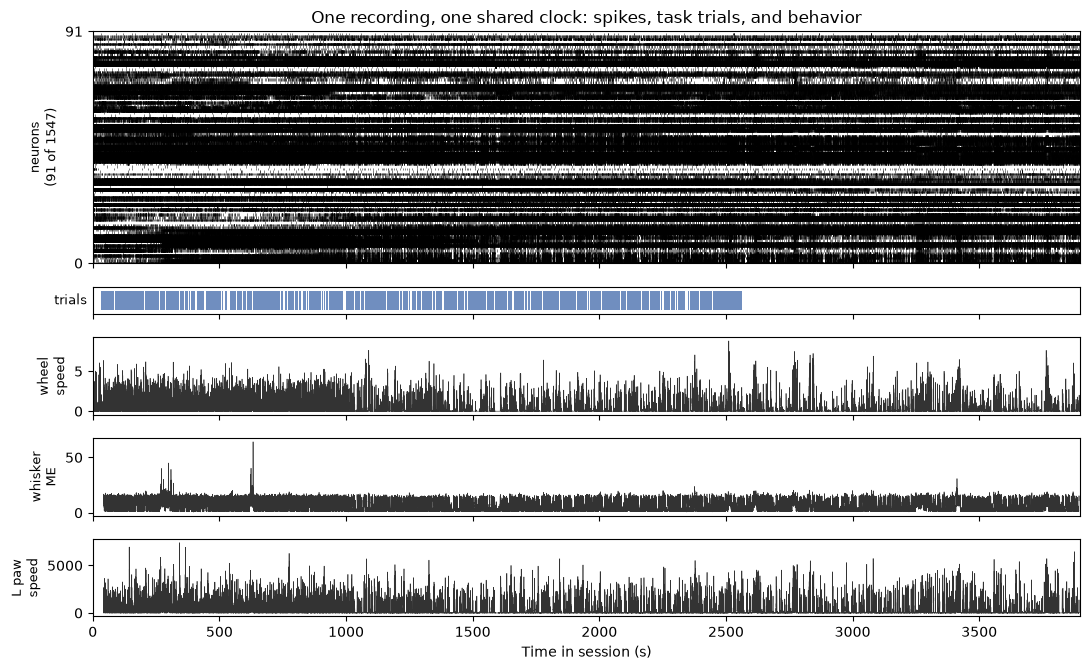

In [6]:
#| code-fold: true
#| code-summary: "Bokeh plotting helpers (spikes, intervals, time series)"
# Small, reusable Bokeh helpers in the same style as the torch-brain tutorials:
# one for an event raster, one for a labelled-interval strip, one for a line.
# Each accepts an x_range so several panels can be locked to one shared time axis.
from bokeh.io import output_notebook, show
from bokeh.layouts import column
from bokeh.models import ColumnDataSource, Range1d
from bokeh.plotting import figure

output_notebook()  # render Bokeh output inline (in the notebook and rendered page)


def plot_spikes(spikes, x_range=None, width=800, height=400):
    """Raster of an event stream, from spikes.timestamps and spikes.unit_index."""
    if x_range is None:
        x_range = (spikes.timestamps[0] * 1e3, spikes.timestamps[-1] * 1e3)
    p = figure(x_axis_label="Time", y_axis_label="Unit index", width=width,
               height=height, x_axis_type="datetime", x_range=x_range, title="Spikes")
    source = ColumnDataSource(data=dict(x=spikes.timestamps * 1e3, y=spikes.unit_index))
    p.scatter("x", "y", source=source, size=5, color="navy", alpha=0.5,
              marker="dash", angle=np.pi / 2)
    return p


def plot_time_series(data, field, index=None, x_range=None, y_axis_label=None,
                     width=800, height=200):
    """Line plot of one field of a time series, breaking the line over domain gaps."""
    if x_range is None:
        x_range = (data.timestamps[0] * 1e3, data.timestamps[-1] * 1e3)
    p = figure(x_axis_label="Time", y_axis_label=y_axis_label or field, width=width,
               height=height, x_axis_type="datetime", x_range=x_range)
    x_values = data.timestamps * 1e3
    y_values = getattr(data, field)
    # Insert NaNs at each domain edge so the line breaks over gaps instead of
    # interpolating straight across them.
    pad = np.nan * np.ones((len(data.domain), *y_values.shape[1:]))
    x_values = np.concatenate([x_values, data.domain.start * 1e3, data.domain.end * 1e3])
    y_values = np.concatenate([y_values, pad, pad])
    order = np.argsort(x_values)
    x_values, y_values = x_values[order], y_values[order]
    if y_values.ndim == 2:
        assert index is not None, "index is required for a 2D field"
        y_values = y_values[:, index]
    source = ColumnDataSource(data=dict(x=x_values, y=y_values))
    p.line(x="x", y="y", source=source, line_width=2, color="green")
    return p


def plot_intervals(*interval, x_range=None, title=None, width=800, height=200):
    """One row of rectangles per Interval passed (each rectangle is one start/end)."""
    colors = ["red", "blue", "green", "orange", "purple", "brown", "pink", "gray", "black"]
    p = figure(title=title, x_axis_label="Time", x_range=x_range, y_axis_label="Intervals",
               y_range=(-len(interval), 1), width=width, height=height, x_axis_type="datetime")
    p.yaxis.visible = False
    for i, iv in enumerate(interval):
        centers = (iv.start + iv.end) / 2.0 * 1e3
        source = ColumnDataSource(data=dict(
            x=centers, width=(iv.end - iv.start) * 1e3, y=np.zeros_like(centers) - i))
        p.rect(x="x", y="y", width="width", height=0.8, source=source,
               fill_color=colors[i % len(colors)], line_color="black", alpha=0.5)
    return p

In [ ]:
import gc
from types import SimpleNamespace

# A fresh handle just for this overview (all reads below are lazy).
ov_rec = BaseDataset(
    dataset_dir=os.path.join(DATA_ROOT, DATASET_DIRNAME),
    recording_ids=[RECORDING_ID],
).get_recording(RECORDING_ID)

T_END = float(ov_rec.domain.end[-1])
spk_t = np.asarray(ov_rec.spikes.timestamps)
spk_u = np.asarray(ov_rec.spikes.unit_index)
n_units = len(ov_rec.units.id)

# Bokeh draws every point in the browser (no rasterization), so for a 65 min
# overview we thin hard: keep ~70 units and cap the raster near a fixed glyph
# budget. Panning/zooming still works, and every panel moves together.
GLYPH_BUDGET = 20_000
keep = np.arange(0, n_units, max(1, n_units // 70))
m = np.isin(spk_u, keep)
sub_t = spk_t[m]
sub_row = np.searchsorted(keep, spk_u[m])  # kept unit id -> compact row index
stride = max(1, len(sub_t) // GLYPH_BUDGET)
raster = SimpleNamespace(timestamps=sub_t[::stride], unit_index=sub_row[::stride])


def _thin(obj, field, target=4000):
    """Stride a 50 Hz signal down to ~target points for a light overview line."""
    ts = np.asarray(obj.timestamps)
    y = np.asarray(getattr(obj, field))
    s = max(1, len(ts) // target)
    sh = SimpleNamespace(timestamps=ts[::s], domain=obj.domain)
    setattr(sh, field, y[::s])
    return sh


# One shared time range links every panel: Bokeh's equivalent of sharex=True.
# Times are passed in milliseconds because the helpers use a datetime x axis.
shared_x = Range1d(0.0, T_END * 1e3)
W = 900

p_raster = plot_spikes(raster, x_range=shared_x, width=W, height=360)
p_raster.title.text = f"One recording, one shared clock ({len(keep)} of {n_units} neurons)"
p_raster.yaxis.axis_label = "neuron (subsampled)"

p_trials = plot_intervals(
    ov_rec.trials, x_range=shared_x, title="task trials", width=W, height=80
)

p_wheel = plot_time_series(_thin(ov_rec.wheel, "speed"), "speed", x_range=shared_x,
                           y_axis_label="wheel speed", width=W, height=130)
p_whisk = plot_time_series(_thin(ov_rec.whisker, "motion_energy"), "motion_energy",
                           x_range=shared_x, y_axis_label="whisker ME", width=W, height=130)
p_paw = plot_time_series(_thin(ov_rec.paws, "left_paw_speed"), "left_paw_speed",
                         x_range=shared_x, y_axis_label="L paw speed", width=W, height=130)

# Only the bottom panel needs to show the (shared) time axis.
for p in (p_raster, p_trials, p_wheel, p_whisk):
    p.xaxis.visible = False
p_paw.xaxis.axis_label = "time in session"

show(column(p_raster, p_trials, p_wheel, p_whisk, p_paw))

# Free the spike arrays we pulled in just for the plot.
del spk_t, spk_u, sub_t, sub_row, raster, ov_rec
_ = gc.collect()

### Lazy loading: pay only for what you touch

This session is **1.93 GB** on disk. Reading all of it into memory at once is
both possible and a bad idea: `materialize()` pulls every array into RAM, and
the footprint below (~1.8 GB) would then be paid again for every session a
foundation model trains on.

In [7]:
import time


def _rss_gb():
    """Resident memory of this process, in GB (Linux; None elsewhere)."""
    try:
        with open("/proc/self/status") as f:
            for line in f:
                if line.startswith("VmRSS:"):
                    return int(line.split()[1]) / 1e6  # kB -> GB
    except OSError:
        return None


fpath = os.path.join(DATA_ROOT, DATASET_DIRNAME, f"{RECORDING_ID}.h5")
print(f"session on disk:              {os.path.getsize(fpath) / 1e9:5.2f} GB")

eager_rec = BaseDataset(
    dataset_dir=os.path.join(DATA_ROOT, DATASET_DIRNAME),
    recording_ids=[RECORDING_ID],
).get_recording(RECORDING_ID)

before = _rss_gb()
t = time.time()
full = eager_rec.materialize()  # read EVERYTHING into memory (what we avoid)
dt = time.time() - t
after = _rss_gb()
if before is not None:
    print(f"materialize() into RAM:       {dt:5.2f} s   (+{after - before:4.2f} GB resident)")
else:
    print(f"materialize() into RAM:       {dt:5.2f} s")

# Drop it again so we do not carry ~1.8 GB through the rest of the notebook.
del full, eager_rec
_ = gc.collect()

session on disk:               1.93 GB


materialize() into RAM:        0.37 s   (+1.86 GB resident)


But a training step never needs the whole session. It reads a short **temporal
slice** and, within it, only the **input** and the **target** (here the spikes
and one behavioral signal). Everything else, every other modality and every
other time point, can stay on disk. That is what lazy loading buys: the
recording is memory-mapped, and you pay (bytes read, RAM used) only for the
attributes and time windows you actually access.

Two examples, with their runtimes:

In [8]:
from torch_brain.utils import bin_spikes

# A fresh, lazily-opened recording (reads no signals).
lazy_rec = BaseDataset(
    dataset_dir=os.path.join(DATA_ROOT, DATASET_DIRNAME),
    recording_ids=[RECORDING_ID],
).get_recording(RECORDING_ID)

# (i) Load a SINGLE attribute: just the wheel speed, and nothing else.
t = time.time()
wheel_speed = np.asarray(lazy_rec.wheel.speed)
dt = (time.time() - t) * 1e3
print(
    f"(i) load wheel.speed only:   {dt:6.2f} ms   "
    f"({wheel_speed.nbytes / 1e6:.2f} MB, the whole 65 min at 50 Hz)"
)

# (ii) Load a SINGLE 1.0 s window: exactly one training sample's worth of data.
mv = lazy_rec.task_aligned_intervals.movement_intervals
t0 = float(np.asarray(mv.start)[10])
t = time.time()
window = lazy_rec.slice(t0, t0 + 1.0)  # crop every modality to [t0, t0 + 1 s]
X = bin_spikes(window.spikes, num_units=len(window.units), bin_size=BIN_SIZE)
y = np.asarray(window.wheel.speed)
dt = (time.time() - t) * 1e3
print(
    f"(ii) slice one 1.0 s window: {dt:6.2f} ms   "
    f"(X = {tuple(X.shape)} binned spikes, y = {y.shape} wheel speed)"
)

(i) load wheel.speed only:     0.16 ms   (1.56 MB, the whole 65 min at 50 Hz)
(ii) slice one 1.0 s window:   1.48 ms   (X = (20, 1547) binned spikes, y = (50,) wheel speed)


::: {.callout-tip}
## Why this matters for neuro foundation models

- **Fast, minimal reads.** Each training step loads only the variables and the
  short time window the model needs, so a step touches megabytes, not gigabytes,
  no matter how large the underlying session is.
- **Store more at no model cost.** The file can keep everything (all units, every
  behavioral signal, raw QC fields, alternative labels) for future benchmarking
  or new tasks. Unused fields cost disk space, not RAM or training time, because
  they are simply never read.
- **Defer processing to the slice.** Since each window is tiny, per-sample steps
  (binning, normalization, adding noise) are cheap to compute on the fly. You can
  reparametrize them, or try variants, without ever reprocessing the file on disk.
:::

### Transforms: deferring computation to each slice

That last point is exactly what a **transform** is: a small function applied to a
window right after the lazy slice and before the model, inside `__getitem__`.
Because it runs per sample on a tiny crop, it is cheap, and swapping or chaining
transforms reshapes the pipeline without touching the data on disk or the model.

Binning is the clearest example. Spikes arrive as an irregular event stream, but
the model wants a regular grid, so each window is binned on the fly. The bin
width is just a parameter: change it and the model input reshapes, with no
reprocessing.

In [9]:
window = lazy_rec.slice(t0, t0 + 1.0)
for bs in (0.02, 0.05, 0.10):
    Xb = bin_spikes(window.spikes, num_units=len(window.units), bin_size=bs)
    print(f"bin_size = {bs:.2f} s  ->  X shape {tuple(Xb.shape)}  (bins x units)")

bin_size = 0.02 s  ->  X shape (50, 1547)  (bins x units)
bin_size = 0.05 s  ->  X shape (20, 1547)  (bins x units)
bin_size = 0.10 s  ->  X shape (10, 1547)  (bins x units)


The same idea extends to context length, augmentation, unit selection, and
sampling jitter: each is a one-line change to the pipeline. The appendix,
*Why this framework is powerful*, works through them.

<!-- =====================================================================
 END OF THE REWORKED "A First Look at the Data" FLOW.

 Everything below is the PREVIOUS version of this section, kept for now.
 When removing it, delete the old exploratory cells (the _peek_ds print,
 "The full session and its causal split", "The behavioral covariates",
 "Spikes, and how a sample is carved out", and "The materialized sample"),
 BUT KEEP the IBLBrainWideMap2025 class definition below: the rest of the
 notebook (datasets, samplers, training) still imports and uses it.
===================================================================== -->

In [5]:
from torch_brain.datasets import Dataset as BaseDataset

_peek_ds = BaseDataset(
    dataset_dir=os.path.join(DATA_ROOT, DATASET_DIRNAME),
    recording_ids=[RECORDING_ID],
)
print(_peek_ds.get_recording(RECORDING_ID))

Data(
behavior_qc=Data(
qc_behavior='PASS',
qc_behavior_paws='PASS',
qc_behavior_wheel='PASS',
qc_behavior_whisker='PASS',
_absolute_start=0.0,
),
brainset=Data(
derived_version='0.0.5',
description='A key challenge in neuroscience is understanding how neurons in hundreds of interconnected brain regions integrate sensory inputs with previous expectations to initiate movements and make decisions. It is difficult to meet this challenge if different laboratories apply different analyses to different recordings in different regions during different behaviours. Here we report a comprehensive set of recordings from 621,733 neurons recorded with 699 Neuropixels probes across 139 mice in 12 laboratories. The data were obtained from mice performing a decision-making task with sensory, motor and cognitive components. The probes covered 279 brain areas in the left forebrain and midbrain and the right hindbrain and cerebellum. We provide an initial appraisal of this brain-wide map and assess how n

**Materialize vs. load.** `brainsets prepare` converts the raw IBL session into
one HDF5 file on disk (~1.9 GB for this session). We never load all of that:
the `Dataset` opens the file and `data.slice(start, end)` reads back only the
short window we ask for. That is what makes training over a 65-minute session
on a laptop practical.


In [6]:
from pathlib import Path
from typing import Literal, TypeAlias, get_args

from torch_brain.datasets import Dataset, DatasetIndex, SpikingDatasetMixin
from torch_brain.transforms import UnitFilter
from torch_brain.utils import bin_spikes

Split: TypeAlias = Literal["train", "val", "test"]


def good_units_mask(units):
    """Keep KiloSort-good, >=1 Hz units on QC-passing probes (the 'filtered' set)."""
    return (
        (np.asarray(units.label) == 1.0)
        & (np.asarray(units.firing_rate) >= 1.0)
        & (np.asarray(units.qc_neural) == b"PASS")
    )


class IBLBrainWideMap2025(SpikingDatasetMixin, Dataset):
    """
    Dataset for the IBL Brain-Wide Map (2025), for a single recording.

    Args:
        root: The root directory of the dataset.
        dirname: The name of the dataset (and the directory containing its data).
        recording_id: The recording id to load.
        split: The split of the dataset (train, val, test), or None to skip
            split-based interval filtering (e.g. when just exploring a recording).
        bin_size: The spike-binning width in seconds. Only required when the
            dataset is actually indexed (i.e. not for exploration-only use).
        filter_units: Whether to restrict to good-quality units (see
            `good_units_mask`).
    """

    # wheel speed is a 1D continuous signal, regularly sampled at BEHAVIOR_SFREQ (50 Hz).
    out_dim = 1
    spiking_dataset_mixin_uniquify_unit_ids = True
    CONTEXT_WINDOW = 1.0  # seconds
    BEHAVIOR_SFREQ = 50  # Hz

    def __init__(
        self,
        root: str,
        recording_id: str,
        dirname: str = "ibl_brain_wide_map_2025",
        split: Split | None = "train",
        bin_size: float | None = None,
        filter_units: bool = True,
    ):
        if split is not None and split not in get_args(Split):
            raise ValueError(
                f"split={split} not well defined, should be one of {get_args(Split)} or None"
            )

        # Single session used by this example (matches recording_ids.txt,
        # kept for the local/brainsets-pipeline workflow described in the
        # README).
        all_recording_ids = ["0802ced5-33a3-405e-8336-b65ebc5cb07c"]
        if recording_id not in all_recording_ids:
            raise ValueError(f"{recording_id!r} not found in recording ids")

        self.dataset_dir = Path(root) / dirname

        super().__init__(
            dataset_dir=self.dataset_dir,
            recording_ids=[recording_id],
            transform=None,
            namespace_attributes=[
                "session.id",
                "subject.id",
                "units.id",
                "probes.id",
            ],
        )

        # store some attributes that are useful later
        self.split = split
        self.recording_id = recording_id
        self.bin_size = bin_size
        self.out_sampling_rate = float(self.BEHAVIOR_SFREQ)  # 50 Hz
        # Each sample spans CONTEXT_WINDOW seconds (1.0 s).
        self.out_samples = round(self.CONTEXT_WINDOW * self.out_sampling_rate)  # 50
        self.num_bins = (
            round(self.CONTEXT_WINDOW / self.bin_size) if self.bin_size else None
        )  # 20 at 0.05 s

        # Move from the unfiltered population to the filtered (good-quality) units.
        # UnitFilter drops the spikes of non-kept units and reindexes, so downstream
        # binning just sees fewer units. num_units is the count the model will get.
        units = self.get_recording(recording_id).units
        if filter_units:
            self._unit_filter = UnitFilter(mask_fn=good_units_mask, field="spikes")
            self.num_units = int(good_units_mask(units).sum())
        else:
            self._unit_filter = None
            self.num_units = len(self.get_unit_ids())
        # Memo cache: the sampler draws the same fixed windows every epoch, and the
        # binned spikes / wheel speed for a window never change. So bin each window
        # once (epoch 1) and reuse the tensors afterwards, avoiding ~100x redundant
        # HDF5 reads + binning.
        self._cache: dict[
            tuple[str, float, float], tuple[torch.Tensor, torch.Tensor]
        ] = {}

    # Contract between Datasets and Samplers:
    # get_sampling_intervals() returns {recording_id: Interval} listing
    # the windows the sampler may draw from.
    # Sampler will emit one DatasetIndex per sample.
    def get_sampling_intervals(self, *_args, **_kwargs):
        rid = self.recording_id
        recording = self.get_recording(rid)

        # Trials aligned to the IBL decision-making task (each is a 1.0 s window).
        intervals = recording.task_aligned_intervals.domain
        # The dataset provides a causal 40/20/40 temporal train/val/test split;
        # intersect with the requested split's domain.
        intervals = intervals & getattr(recording, f"{self.split}_domain")
        # Wheel decoding is scored within the movement window of each trial.
        intervals = intervals & recording.task_aligned_intervals.movement_intervals
        # And only where the wheel signal itself is defined.
        intervals = intervals & recording.wheel._domain
        return {rid: intervals}

    # `index` is a DatasetIndex(recording_id, start, end) produced by the sampler.
    def __getitem__(self, index: DatasetIndex):
        # Return the cached tensors if we have already binned this exact window.
        key = (index.recording_id, index.start, index.end)
        if key in self._cache:
            return self._cache[key]

        # Slice the recording to this sample's time window; all modalities
        # (.spikes, .units, .wheel.speed, ...) are cropped (lazily).
        recording = self.get_recording(index.recording_id)
        data = recording.slice(index.start, index.end)

        # Keep only the good-quality units (no-op when filter_units=False).
        if self._unit_filter is not None:
            data = self._unit_filter(data)

        # All models take (num_bins, num_units) and return (out_samples, out_dim).

        # Spikes are an irregular event stream -> bin them into a regular grid.
        X = bin_spikes(data.spikes, num_units=len(data.units), bin_size=self.bin_size)
        X = torch.from_numpy(X).float()  # shape: (num_bins, num_units)

        # Wheel speed is already regularly sampled at 50 Hz. It is NOT normalized.
        Y = np.asarray(data.wheel.speed, dtype=np.float32)  # shape: (out_samples,)
        Y = torch.from_numpy(Y).unsqueeze(-1)  # shape: (out_samples, out_dim=1)

        self._cache[key] = (X, Y)
        return X, Y


# The dataset class handles file I/O; here we open the session just to explore it.
viz_ds = IBLBrainWideMap2025(root=DATA_ROOT, recording_id=RECORDING_ID, split=None)
viz_rec = viz_ds.get_recording(RECORDING_ID)
T_END = float(viz_rec.domain.end[-1])
print(f"Session length: {T_END:.0f} s ({T_END / 60:.0f} min)")
print(f"Neurons: {len(viz_rec.units.id)}  |  covariates: wheel, whisker, paws")

Session length: 3898 s (65 min)
Neurons: 1547  |  covariates: wheel, whisker, paws


### The full session and its causal split

The dataset splits the session **causally** in time: train is the early part,
then val, then test (a 40/20/40 temporal split). Each grey tick below is one
1.0 s window the sampler may draw a sample from.

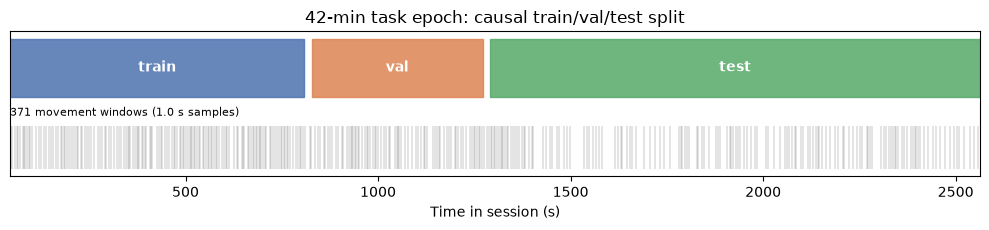

In [7]:
splits = {
    "train": (viz_rec.train_domain, "#4C72B0"),
    "val": (viz_rec.val_domain, "#DD8452"),
    "test": (viz_rec.test_domain, "#55A868"),
}
ti = viz_rec.task_aligned_intervals.domain  # used only to bound the x-axis on the first/last trial
mi = viz_rec.task_aligned_intervals.movement_intervals

x_start = float(ti.start[0])
x_end = float(ti.end[-1])

fig, ax = plt.subplots(figsize=(10, 2.4))
bar_ymin, bar_ymax = 0.55, 0.95
for name, (dom, color) in splits.items():
    for s, e in zip(np.asarray(dom.start), np.asarray(dom.end)):
        ax.axvspan(s, e, ymin=bar_ymin, ymax=bar_ymax, color=color, alpha=0.85)
    vis_start = max(x_start, float(dom.start[0]))
    vis_end = min(x_end, float(dom.end[-1]))
    mid = (vis_start + vis_end) / 2
    ax.text(
        mid,
        (bar_ymin + bar_ymax) / 2,
        name,
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
    )
# movement windows: the subset used as decoding samples
ax.vlines(np.asarray(mi.start), 0.05, 0.35, color="k", lw=0.3, alpha=0.5)
ax.text(
    x_start,
    0.40,
    f"{len(mi.start)} movement windows (1.0 s samples)",
    ha="left",
    va="bottom",
    fontsize=8,
)
ax.set_xlim(x_start, x_end)
ax.set_ylim(0.0, 1.0)
ax.set_yticks([])
ax.set_xlabel("Time in session (s)")
ax.set_title(
    f"{(x_end - x_start) / 60:.0f}-min task epoch: causal train/val/test split"
)
plt.tight_layout()
plt.show()

### The behavioral covariates

These are the signals available as decoding targets, shown over a 30 s window.
Movement windows are shaded green and go-cue times marked with orange dashes.
In this example we decode `wheel speed`, but the framework exposes all of them.

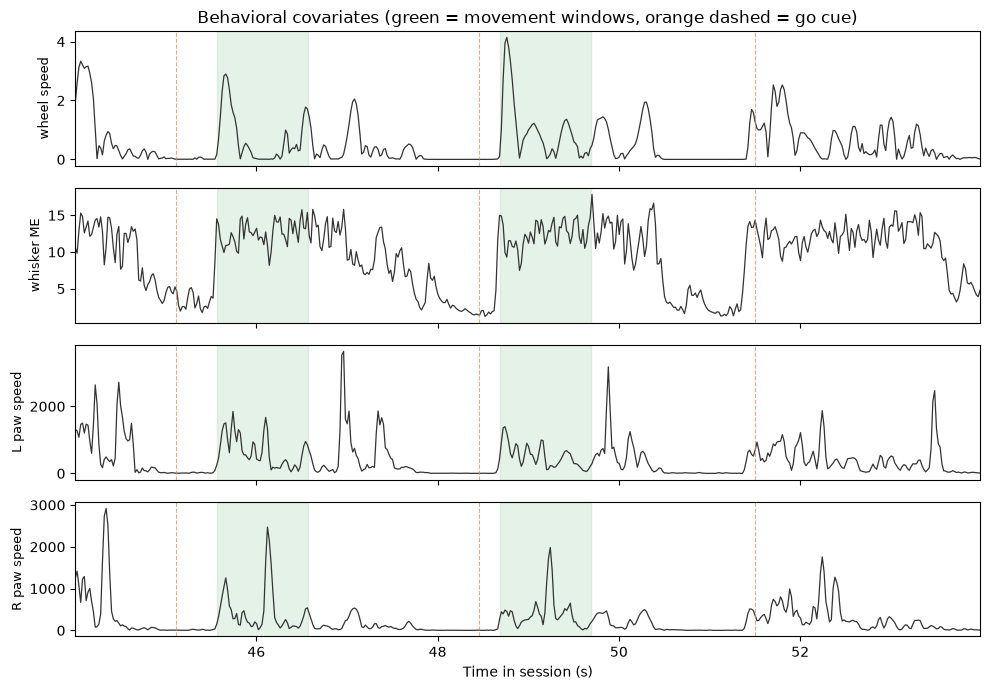

In [8]:
T0, T1 = 44.0, 54.0  # a legible 30 s window inside the training split

# Read go-cue times from a throwaway handle: accessing trials.go_cue_time on a
# recording leaves its lazy interval in a state that later breaks data.slice(),
# so we keep viz_rec clean for the materialize step below.
_go_rec = IBLBrainWideMap2025(
    root=DATA_ROOT, recording_id=RECORDING_ID, split=None
).get_recording(RECORDING_ID)
go = np.asarray(_go_rec.get_nested_attribute("trials.go_cue_time"))
go = go[(go >= T0) & (go <= T1)]
mv = [
    (s, e)
    for s, e in zip(np.asarray(mi.start), np.asarray(mi.end))
    if s >= T0 and e <= T1
]

covariates = [
    ("wheel", "speed", "wheel speed"),
    ("whisker", "motion_energy", "whisker ME"),
    ("paws", "left_paw_speed", "L paw speed"),
    ("paws", "right_paw_speed", "R paw speed"),
]
fig, axes = plt.subplots(len(covariates), 1, figsize=(10, 7), sharex=True)
for ax, (ns, attr, label) in zip(axes, covariates):
    obj = getattr(viz_rec, ns)
    ts = np.asarray(obj.timestamps)
    msk = (ts >= T0) & (ts <= T1)
    ax.plot(ts[msk], np.asarray(getattr(obj, attr))[msk], lw=0.9, color="#333333")
    for s, e in mv:
        ax.axvspan(s, e, color="#55A868", alpha=0.15)
    for g in go:
        ax.axvline(g, color="#DD8452", lw=0.8, ls="--", alpha=0.7)
    ax.set_ylabel(label, fontsize=9)
    ax.margins(x=0)
axes[0].set_title(
    "Behavioral covariates (green = movement windows, orange dashed = go cue)"
)
axes[-1].set_xlabel("Time in session (s)")
plt.tight_layout()
plt.show()

### Spikes, and how a sample is carved out

The spikes are an irregular event stream over the whole session. The sampler
picks fixed 1.0 s windows out of it (one highlighted below); everything outside
the window is simply never read.

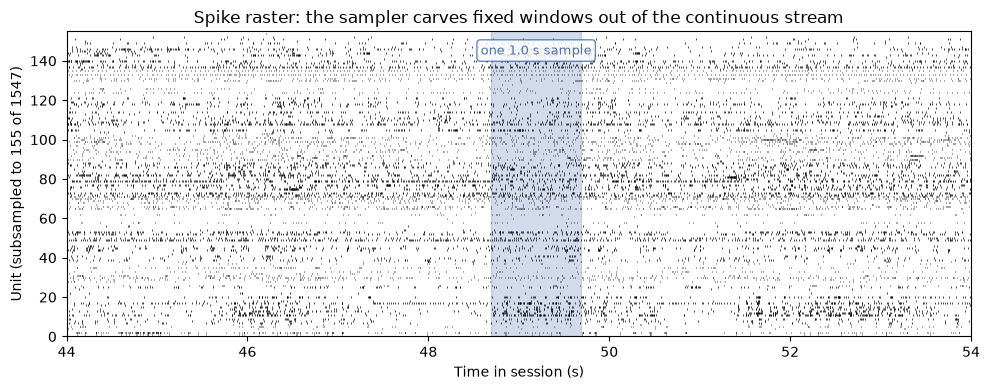

In [9]:
allt = np.asarray(viz_rec.spikes.timestamps)
allu = np.asarray(viz_rec.spikes.unit_index)
wm = (allt >= T0) & (allt <= T1)
st, ui = allt[wm], allu[wm]

# subsample ~150 units so the raster stays legible
n_units = len(viz_rec.units.id)
keep = np.arange(0, n_units, max(1, n_units // 150))
row_of = {u: i for i, u in enumerate(keep)}
m = np.isin(ui, keep)
rows = np.array([row_of[u] for u in ui[m]])

# highlight one real sampling window (task-aligned & movement & wheel-defined)
sample_iv = (
    viz_rec.task_aligned_intervals.domain
    & viz_rec.train_domain
    & viz_rec.task_aligned_intervals.movement_intervals
    & viz_rec.wheel._domain
)
in_win = [
    (s, e)
    for s, e in zip(np.asarray(sample_iv.start), np.asarray(sample_iv.end))
    if s >= T0 and e <= T1
]
hs, he = in_win[len(in_win) // 2]

fig, ax = plt.subplots(figsize=(10, 4))
spikes_by_row = [st[m][rows == r] for r in range(len(keep))]
ax.eventplot(
    spikes_by_row,
    colors="k",
    lineoffsets=list(range(len(keep))),
    linelengths=0.8,
    linewidths=0.5,
)
ax.axvspan(hs, he, color="#4C72B0", alpha=0.25)
ax.text(
    (hs + he) / 2,
    len(keep) * 0.96,
    "one 1.0 s sample",
    color="#4C72B0",
    fontsize=9,
    ha="center",
    va="top",
    bbox=dict(boxstyle="round", fc="white", ec="#4C72B0", alpha=0.85),
)
ax.set_xlim(T0, T1)
ax.set_ylim(0, len(keep))
ax.set_xlabel("Time in session (s)")
ax.set_ylabel(f"Unit (subsampled to {len(keep)} of {n_units})")
ax.set_title(
    "Spike raster: the sampler carves fixed windows out of the continuous stream"
)
plt.tight_layout()
plt.show()

### The materialized sample

Finally, `data.slice(start, end)` returns exactly that window, and binning the
spikes turns it into the `(bins x units)` input `X`; the aligned wheel speed is
the target `Y`. This `(X, Y)` pair is precisely what the model will see.

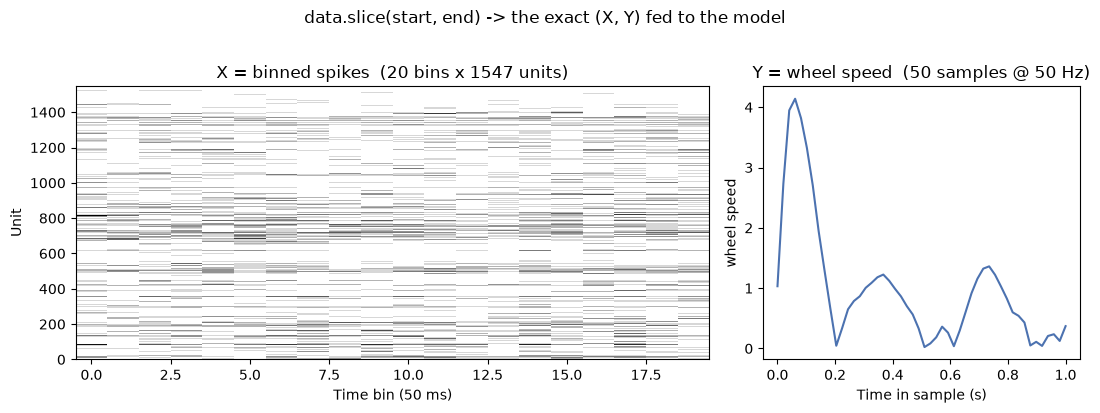

In [10]:
sample = viz_rec.slice(hs, he)
X_demo = bin_spikes(sample.spikes, num_units=len(sample.units), bin_size=BIN_SIZE)
Y_demo = np.asarray(sample.wheel.speed, dtype=np.float32)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [2, 1]})
# log1p for contrast: per-bin counts are small, so raw values look nearly blank
axes[0].imshow(
    np.log1p(X_demo.T),
    aspect="auto",
    cmap="Greys",
    origin="lower",
    interpolation="nearest",
)
axes[0].set_title(
    f"X = binned spikes  ({X_demo.shape[0]} bins x {X_demo.shape[1]} units)"
)
axes[0].set_xlabel(f"Time bin ({BIN_SIZE * 1000:.0f} ms)")
axes[0].set_ylabel("Unit")
tt = np.linspace(0, 1.0, len(Y_demo))
axes[1].plot(tt, Y_demo, color="#4C72B0")
axes[1].set_title(f"Y = wheel speed  ({len(Y_demo)} samples @ 50 Hz)")
axes[1].set_xlabel("Time in sample (s)")
axes[1].set_ylabel("wheel speed")
fig.suptitle("data.slice(start, end) -> the exact (X, Y) fed to the model", y=1.02)
plt.tight_layout()
plt.show()

## Defining a Simple & Custom Dataset

`IBLBrainWideMap2025` (defined above) is a `brainsets`-backed dataset for a
single recording. Two methods matter for the wheel-speed task:
- **`get_sampling_intervals`**: Decides *which* time windows count as samples.
  For wheel-speed decoding, each sample is a fixed **1.0 s** window drawn from
  the trials of the IBL decision-making task, restricted to the movement window
  and to the times where the wheel signal is defined. We use the dataset's
  built-in **causal** train/val/test split (`{split}_domain`): a temporal
  40/20/40 split, so train is early in the session and test is late.
- **`__getitem__`**: Given a time-sliced sample, turns it into model Tensors.

Note: `wheel_speed` is intentionally **not normalized** (unlike the
pixel-valued whisker/paw signals), so we use the raw signal as the target.
(If you swap in another covariate as the target, normalization may matter.)

**Unfiltered vs. filtered units.** The recording ships with *all*
recorded units (the TS1 default: no QC filtering). We move to the **filtered**
set here via a `UnitFilter` transform that keeps only good-quality units:
`label == 1.0` (KiloSort "good") AND `firing_rate >= 1 Hz` AND
`qc_neural == PASS` (probe QC). For this session that is **1547 -> 358 units**.
Fewer, higher-quality units means a much lower-dimensional input, which
directly reduces the overfitting we saw with the full population.


## Creating the Datasets, Samplers, and DataLoaders

💡 This is where we come across the main pattern for creating data pipelines with TorchBrain:
- **Dataset** tells the sampler *where sampling is allowed*,
- **Sampler** decides *what* samples to load (by emitting `DatasetIndex` objects), and
- **DataLoader** batches the samples as usual.

In [11]:
from torch.utils.data import DataLoader  # standard PyTorch loader
from torch_brain.samplers import TrialSampler

train_ds = IBLBrainWideMap2025(
    DATA_ROOT, split="train", bin_size=BIN_SIZE, recording_id=RECORDING_ID
)
# We want to sample "one-trial-at-a-time", so we use the TrialSampler
train_sampler = TrialSampler(
    sampling_intervals=train_ds.get_sampling_intervals(),
    shuffle=True,
)
# Note the sampler is passed explicitly; it is not the default random/sequential
# sampler PyTorch picks for an indexable dataset.
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
)
print(f"Number of units: {train_ds.num_units}")
print(f"Number of training samples: {len(train_sampler)}")

# Validation Dataset, Sampler, and DataLoader
val_ds = IBLBrainWideMap2025(
    DATA_ROOT, split="val", bin_size=BIN_SIZE, recording_id=RECORDING_ID
)
val_sampler = TrialSampler(sampling_intervals=val_ds.get_sampling_intervals())
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    sampler=val_sampler,
)
print(f"Number of validation samples: {len(val_sampler)}")

# Test Dataset, Sampler, and DataLoader.
# The test split is the *late* part of the session (causal split). We touch it
# only once, for the final score after training/model selection is done.
test_ds = IBLBrainWideMap2025(
    DATA_ROOT, split="test", bin_size=BIN_SIZE, recording_id=RECORDING_ID
)
test_sampler = TrialSampler(sampling_intervals=test_ds.get_sampling_intervals())
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    sampler=test_sampler,
)
print(f"Number of test samples: {len(test_sampler)}")

print(f"Number of units:  {train_ds.num_units}")
print(f"Bins per sample:  {train_ds.num_bins}  (bin size = {BIN_SIZE}s)")
print(f"Target samples:   {train_ds.out_samples}  (at {train_ds.out_sampling_rate} Hz)")
print(
    f"Train trials:     {len(train_ds.get_sampling_intervals()[train_ds.recording_id])}"
)
print(f"Val trials:       {len(val_ds.get_sampling_intervals()[val_ds.recording_id])}")

Number of units: 358
Number of training samples: 148
Number of validation samples: 72
Number of test samples: 145
Number of units:  358
Bins per sample:  20  (bin size = 0.05s)
Target samples:   50  (at 50.0 Hz)
Train trials:     148
Val trials:       72


Let's first peek at a single sample to confirm the shapes match what we expect,
and visualize the binned spikes (input) and wheel speed (target) for one trial.

First sample:
    recording_id: 0802ced5-33a3-405e-8336-b65ebc5cb07c,
    start time: 517.7887552706264,
    end time: 518.7887552706264

X shape: (20, 358)  (num_bins, num_units)
Y shape: (50, 1)  (out_samples, out_dim)


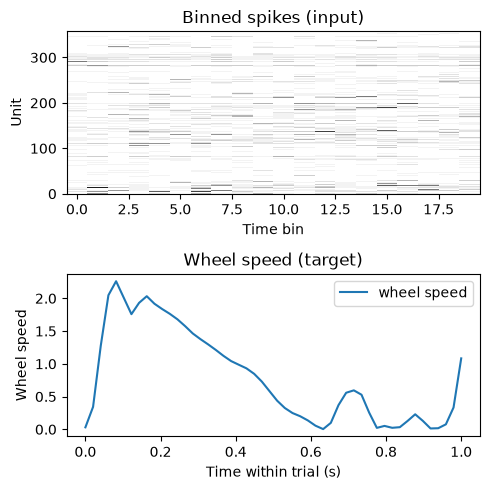

In [12]:
first_sample_index = next(iter(train_sampler))
print(
    f"First sample:\n"
    f"    recording_id: {first_sample_index.recording_id},\n"
    f"    start time: {first_sample_index.start},\n"
    f"    end time: {first_sample_index.end}\n"
)

X, Y = train_ds[first_sample_index]
print(f"X shape: {tuple(X.shape)}  (num_bins, num_units)")
print(f"Y shape: {tuple(Y.shape)}  (out_samples, out_dim)")

fig, axes = plt.subplots(2, 1, figsize=(5, 5))

axes[0].imshow(
    X.T.numpy(), aspect="auto", cmap="Greys", origin="lower", interpolation="nearest"
)
axes[0].set_title("Binned spikes (input)")
axes[0].set_xlabel("Time bin")
axes[0].set_ylabel("Unit")

t = np.linspace(0.0, train_ds.CONTEXT_WINDOW, train_ds.out_samples)
axes[1].plot(t, Y[:, 0].numpy(), label="wheel speed")
axes[1].set_title("Wheel speed (target)")
axes[1].set_xlabel("Time within trial (s)")
axes[1].set_ylabel("Wheel speed")
axes[1].legend()

plt.tight_layout()
plt.show()

## The Model

Three small decoders are defined in the cells below: Linear, GRU, and TCN.

- **Linear**: flatten + a single `nn.Linear` layer.
- **GRU**: bidirectional GRU, then a per-timestep linear readout and an
  interpolation to upsample from `num_bins` to `out_samples`.
- **TCN**: a stack of dilated 1D convolutions, followed by the same
  interpolation + readout.

All three follow the same interface. They take `(batch, num_bins, num_units)`
and return `(batch, out_samples, out_dim)`.

### Linear

In [13]:
class Linear(nn.Module):
    def __init__(self, in_units, in_bins, out_dim, out_samples, dropout=0.2):
        super().__init__()
        self.out_dim = out_dim
        self.out_samples = out_samples

        input_size = in_units * in_bins
        output_size = out_dim * out_samples
        self.net = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(input_size, output_size)
        )

    def forward(self, x: Tensor) -> Tensor:
        batch_size = x.size(0)
        y = self.net(x.flatten(start_dim=1))
        y = y.view(batch_size, self.out_samples, self.out_dim)
        return y

### GRU

In [14]:
class GRU(nn.Module):
    def __init__(
        self,
        in_units,
        in_bins,
        out_dim,
        out_samples,
        hidden_dim=64,
        num_layers=2,
        bidirectional=True,
        dropout=0.2,
    ):
        super().__init__()
        self.out_dim = out_dim
        self.out_samples = out_samples

        self.gru = nn.GRU(
            input_size=in_units,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout,
        )
        self.readout = nn.Linear(
            in_features=2 * hidden_dim if bidirectional else hidden_dim,
            out_features=out_dim,
        )

    def forward(self, x: Tensor) -> Tensor:
        z, _ = self.gru(x)
        y = self.readout(z)
        y = y.permute(0, 2, 1)  # (B, T, D) ->  (B, D, T)
        y = nn.functional.interpolate(y, self.out_samples, mode="linear")
        y = y.permute(0, 2, 1)  # (B, D, T) -> (B, T, D)
        return y

### TCN

In [15]:
class TCN(nn.Module):
    def __init__(
        self,
        in_units,
        in_bins,
        out_dim,
        out_samples,
        hidden_dim=64,
        num_layers=8,
        kernel_size=3,
        dropout=0.2,
    ):
        super().__init__()
        self.out_dim = out_dim
        self.out_samples = out_samples

        layers = []
        in_channels = in_units
        for i in range(num_layers):
            dilation = 2**i
            padding = (kernel_size - 1) * dilation // 2
            layers.append(nn.Dropout(dropout))
            layers.append(
                nn.Conv1d(
                    in_channels,
                    hidden_dim,
                    kernel_size,
                    padding=padding,
                    dilation=dilation,
                )
            )
            layers.append(nn.ReLU())
            in_channels = hidden_dim
        self.net = nn.Sequential(*layers)
        self.readout = nn.Linear(hidden_dim, out_dim)

    def forward(self, x: Tensor) -> Tensor:
        z = x.permute(0, 2, 1)  # (B, T, C) -> (B, C, T)
        z = self.net(z)
        z = nn.functional.interpolate(z, self.out_samples, mode="linear")
        z = z.permute(0, 2, 1)  # (B, C, T) -> (B, T, C)
        y = self.readout(z)
        return y

### Instantiating the model

In [16]:
model = TCN(  # try: Linear, GRU, TCN
    in_units=train_ds.num_units,
    in_bins=train_ds.num_bins,
    out_dim=train_ds.out_dim,
    out_samples=train_ds.out_samples,
).to(device)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {num_params:,}")
print(model)


Trainable parameters: 155,329
TCN(
  (net): Sequential(
    (0): Dropout(p=0.2, inplace=False)
    (1): Conv1d(358, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
    (8): ReLU()
    (9): Dropout(p=0.2, inplace=False)
    (10): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
    (11): ReLU()
    (12): Dropout(p=0.2, inplace=False)
    (13): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
    (14): ReLU()
    (15): Dropout(p=0.2, inplace=False)
    (16): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
    (17): ReLU()
    (18): Dropout(p=0.2, inplace=False)
    (19): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(64,), 

## Training

A standard PyTorch loop! MSE loss against the wheel speed, AdamW optimizer,
R² score on the validation set at the end of each epoch.

In [17]:
from sklearn.metrics import r2_score

optim = torch.optim.AdamW(model.parameters(), lr=LR)

val_r2_history = []

for _epoch in (epoch_pbar := tqdm(range(EPOCHS))):
    model.train()
    for X, Y in train_loader:
        X, Y = X.to(device), Y.to(device)
        pred = model(X)
        loss = nn.functional.mse_loss(pred, Y)
        optim.zero_grad()
        loss.backward()
        optim.step()

    with torch.no_grad():
        model.eval()
        preds, targets = [], []
        for X, Y in val_loader:
            X, Y = X.to(device), Y.to(device)
            preds.append(model(X))
            targets.append(Y)
        pred = torch.cat(preds).flatten(0, 1).cpu()
        target = torch.cat(targets).flatten(0, 1).cpu()
        r2 = r2_score(target, pred)
        val_r2_history.append(r2)
        epoch_pbar.set_description(f"Val R²: {r2:.3f}")

  0%|          | 0/100 [00:00<?, ?it/s]

## Evaluation

Plot the R² curve over training and compare predicted vs. actual wheel speed
on one validation trial.

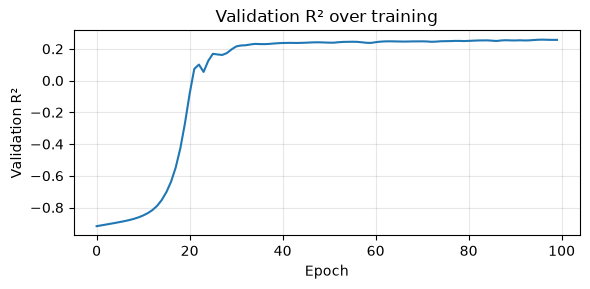

In [18]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(val_r2_history)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation R²")
ax.set_title("Validation R² over training")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Let's look at an example of how our model's predictions compare with the ground truth!

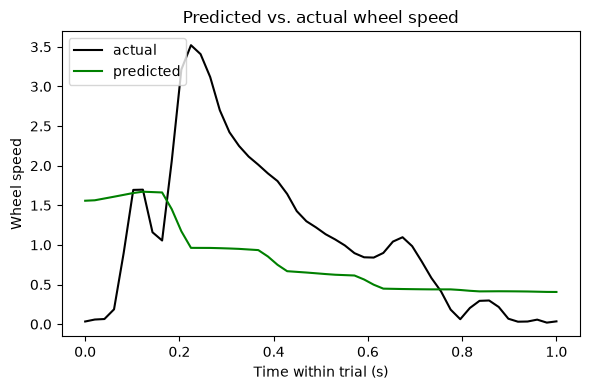

In [19]:
model.eval()
with torch.no_grad():
    X, Y = val_ds[next(iter(val_sampler))]
    pred = model(X.unsqueeze(0).to(device)).squeeze(0).cpu()

t = np.linspace(0.0, val_ds.CONTEXT_WINDOW, val_ds.out_samples)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t, Y[:, 0].numpy(), label="actual", color="k")
ax.plot(t, pred[:, 0].numpy(), label="predicted", color="green")
ax.set_xlabel("Time within trial (s)")
ax.set_ylabel("Wheel speed")
ax.set_title("Predicted vs. actual wheel speed")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

## Final Test Evaluation

The **test** split is the *late* portion of the session (the causal split), held
out from training and model selection. We score it exactly **once**, here, to get
an honest estimate of decoding performance. Because the split is temporal rather
than shuffled, test R² is typically **lower** than validation R² -- that gap
reflects within-session nonstationarity, which is exactly what a causal split is
designed to expose.

In [20]:
model.eval()
with torch.no_grad():
    preds, targets = [], []
    for X, Y in test_loader:
        X, Y = X.to(device), Y.to(device)
        preds.append(model(X))
        targets.append(Y)
    test_pred = torch.cat(preds).flatten(0, 1).cpu()
    test_target = torch.cat(targets).flatten(0, 1).cpu()

test_r2 = r2_score(test_target, test_pred)
best_val_r2 = max(val_r2_history)
print(f"Best validation R²: {best_val_r2:.3f}")
print(f"Final test R²:      {test_r2:.3f}")

Best validation R²: 0.258
Final test R²:      -0.084


And the predicted vs. actual wheel speed on one held-out test trial:

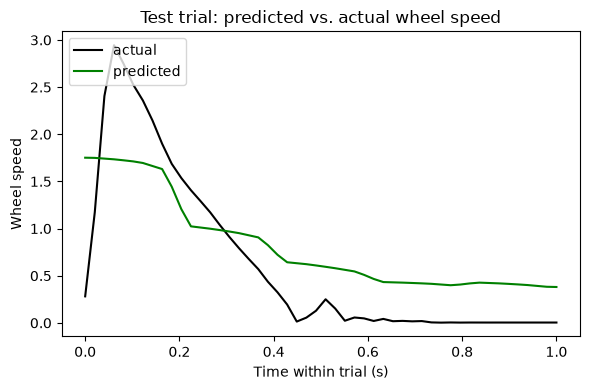

In [21]:
model.eval()
with torch.no_grad():
    X, Y = test_ds[next(iter(test_sampler))]
    pred = model(X.unsqueeze(0).to(device)).squeeze(0).cpu()

t = np.linspace(0.0, test_ds.CONTEXT_WINDOW, test_ds.out_samples)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t, Y[:, 0].numpy(), label="actual", color="k")
ax.plot(t, pred[:, 0].numpy(), label="predicted", color="green")
ax.set_xlabel("Time within trial (s)")
ax.set_ylabel("Wheel speed")
ax.set_title("Test trial: predicted vs. actual wheel speed")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

# Hands On: Decode a Different Covariate

Now it's your turn. Everything you need is already defined above: the dataset
class, the samplers, and the training loop. This exercise focuses on the one
piece that changes when you decode a new signal: **what `__getitem__` returns
as `Y`**.

**Goal:** instead of wheel speed, decode one of the other covariates recorded
in this session: `whisker.motion_energy`, `paws.left_paw_speed`, or
`paws.right_paw_speed` (see "The behavioral covariates" above for what these
look like).

**Steps:**
1. Pick a covariate from the list above.
2. Subclass `IBLBrainWideMap2025` (skeleton below) and point `Y` at your
   chosen covariate instead of `data.wheel.speed`.
3. Instantiate train/val/test datasets, samplers, and loaders for your new
   class, exactly as in "Creating the Datasets, Samplers, and DataLoaders".
4. Re-run the training loop on a fresh model instance, and compare its
   validation R² to wheel speed's.

This is a self-check: if your new covariate trains and its R² is in a
plausible range, your subclass is wired correctly. If you want to go further,
this is also the natural place to try the transforms from the appendix below
(a finer bin size, a longer context window, unit dropout, ...) on your new
target.


In [22]:
class IBLCovariateDataset(IBLBrainWideMap2025):
    """Same as IBLBrainWideMap2025, but decodes `namespace.attr` instead of wheel speed."""

    def __init__(self, *args, namespace: str, attr: str, **kwargs):
        super().__init__(*args, **kwargs)
        self.namespace = namespace
        self.attr = attr

    def __getitem__(self, index):
        key = (index.recording_id, index.start, index.end)
        if key in self._cache:
            return self._cache[key]

        recording = self.get_recording(index.recording_id)
        data = recording.slice(index.start, index.end)
        if self._unit_filter is not None:
            data = self._unit_filter(data)

        X = bin_spikes(data.spikes, num_units=len(data.units), bin_size=self.bin_size)
        X = torch.from_numpy(X).float()

        # TODO: read your chosen covariate instead of the wheel speed, e.g.
        # Y = np.asarray(getattr(getattr(data, self.namespace), self.attr), dtype=np.float32)
        Y = np.asarray(data.wheel.speed, dtype=np.float32)  # <-- replace this line
        Y = torch.from_numpy(Y).unsqueeze(-1)

        self._cache[key] = (X, Y)
        return X, Y


# TODO: pick a covariate to decode
NAMESPACE = "whisker"  # try: "whisker", "paws"
ATTR = "motion_energy"  # try: "motion_energy", "left_paw_speed", "right_paw_speed"

# TODO: build train/val/test IBLCovariateDataset instances (passing
# namespace=NAMESPACE, attr=ATTR), wrap each in a TrialSampler + DataLoader
# (same pattern as "Creating the Datasets, Samplers, and DataLoaders" above),
# then re-run the training loop on a fresh model instance and compare its
# validation R² to wheel speed's.

---
# Appendix: Why this framework is powerful

The training pipeline above is four independent pieces: **Dataset** (*where* to
sample), **Sampler** (*which* windows), **Transform** (*how* to process), and
**DataLoader** (*how* to batch). Because they are decoupled, common neuroscience
experiments (finer binning, more context, augmentation, region ablations,
jittered sampling) are each a **one-line change that never touches the model or
the training loop**.

Every cell below is illustrative: it operates on a single demo window and does
**not** modify the tuned pipeline above.

In [23]:
from torch_brain.samplers import RandomFixedWindowSampler
from torch_brain.transforms import Compose, RandomCrop, UnitDropout

# a clean recording handle + one real sampling window to demo on
demo_ds = IBLBrainWideMap2025(root=DATA_ROOT, recording_id=RECORDING_ID, split=None)
demo_rec = demo_ds.get_recording(RECORDING_ID)
demo_iv = (
    demo_rec.task_aligned_intervals.domain
    & demo_rec.train_domain
    & demo_rec.task_aligned_intervals.movement_intervals
    & demo_rec.wheel._domain
)
DEMO_T0 = float(demo_iv.start[10])
print(f"Demo window starts at {DEMO_T0:.2f} s")

Demo window starts at 93.46 s


## 1. Lazy loading and the time gain

A `brainsets` recording is memory-mapped: `data.slice(start, end)` reads only
the bytes for the window you ask for. You open a ~2 GB session in milliseconds
and each sample touches a tiny slice of it, so you never hold the session (or
even one full modality) in RAM. That is what makes training over a 65-min
session, or scaling to many sessions, feasible at all.

The catch (see the caching in `IBLBrainWideMap2025`): lazy is cheap *per
call* but you redo it *every epoch*. So the sweet spot is **lazy + selective
materialization**: never eagerly load the whole file, but cache the handful of
windows you actually sample, once. Lazy decides what you *never* load; the cache
decides what you load *only once*.

In [24]:
import os
import time

fpath = os.path.join(DATA_ROOT, "ibl_brain_wide_map_2025", f"{RECORDING_ID}.h5")
print(f"session file on disk:       {os.path.getsize(fpath) / 1e9:5.2f} GB")

t = time.time()
_d = IBLBrainWideMap2025(root=DATA_ROOT, recording_id=RECORDING_ID, split=None)
_r = _d.get_recording(RECORDING_ID)
t_open = time.time() - t

t = time.time()
for _ in range(20):
    _s = _r.slice(DEMO_T0, DEMO_T0 + 1.0)
    _ = bin_spikes(_s.spikes, num_units=len(_s.units), bin_size=BIN_SIZE)
t_slice = (time.time() - t) / 20

t = time.time()
_allt = np.asarray(_r.spikes.timestamps)
t_all = time.time() - t

print(f"open dataset (lazy):        {t_open * 1000:5.1f} ms   (reads no signals)")
print(
    f"one 1.0 s window slice+bin: {t_slice * 1000:5.1f} ms   (reads only that window)"
)
_all_mb = _allt.nbytes / 1e6
print(
    f"load ALL spike timestamps:  {t_all * 1000:5.0f} ms   ({_all_mb:.0f} MB, one modality)"
)

session file on disk:        1.93 GB
open dataset (lazy):          7.7 ms   (reads no signals)
one 1.0 s window slice+bin:   1.0 ms   (reads only that window)
load ALL spike timestamps:     39 ms   (468 MB, one modality)


## 2. Change the bin size

Binning is one parameter. Finer bins give more temporal resolution but a
higher-dimensional, sparser input; coarser bins regularize. The model still
just receives `(num_bins, num_units)`.

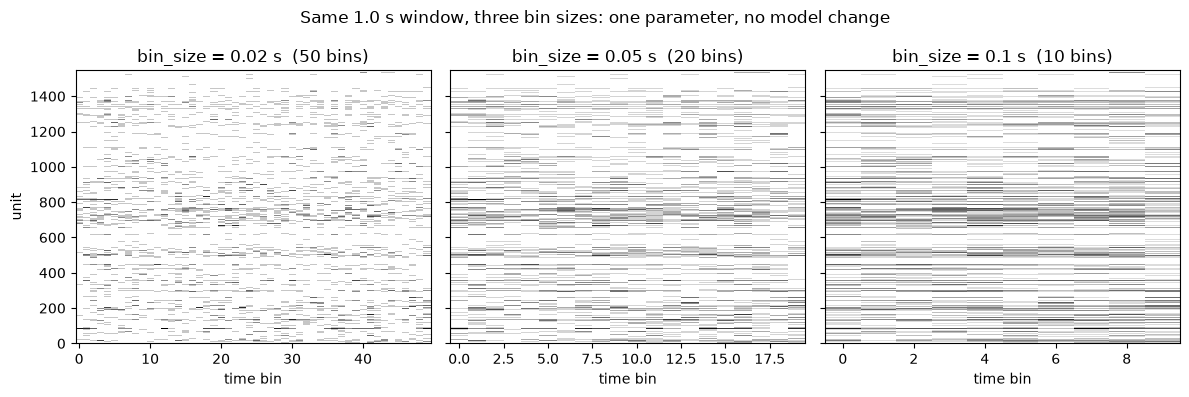

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, bs in zip(axes, [0.02, 0.05, 0.1]):
    s = demo_rec.slice(DEMO_T0, DEMO_T0 + 1.0)
    Xd = bin_spikes(s.spikes, num_units=len(s.units), bin_size=bs)
    ax.imshow(
        np.log1p(Xd.T),
        aspect="auto",
        cmap="Greys",
        origin="lower",
        interpolation="nearest",
    )
    ax.set_title(f"bin_size = {bs} s  ({Xd.shape[0]} bins)")
    ax.set_xlabel("time bin")
axes[0].set_ylabel("unit")
fig.suptitle("Same 1.0 s window, three bin sizes: one parameter, no model change")
plt.tight_layout()
plt.show()

## 3. Longer or shorter context window

The context window is how much time each sample spans; it lives in the
sampler/slice length, not in the data. A 2.0 s window simply yields 100 target
samples (at 50 Hz) and `2.0 / bin_size` input bins.

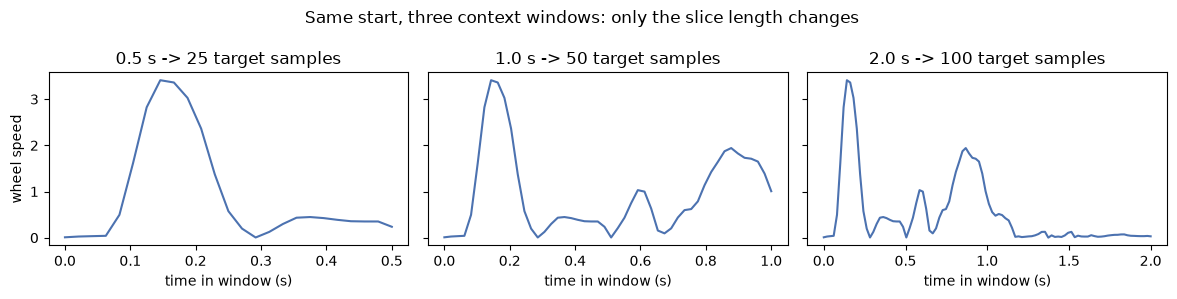

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for ax, L in zip(axes, [0.5, 1.0, 2.0]):
    s = demo_rec.slice(DEMO_T0, DEMO_T0 + L)
    y = np.asarray(s.wheel.speed)
    ax.plot(np.linspace(0, L, len(y)), y, color="#4C72B0")
    ax.set_title(f"{L} s -> {len(y)} target samples")
    ax.set_xlabel("time in window (s)")
axes[0].set_ylabel("wheel speed")
fig.suptitle("Same start, three context windows: only the slice length changes")
plt.tight_layout()
plt.show()

## 4. Augmentation via composable transforms

Transforms attach with `transform=` and chain with `Compose`; they run inside
`__getitem__`, so augmentation is re-drawn every epoch. Here a random 0.8 s crop
of the same window (a different crop each call). *(Time-warping augmentations
like `RandomTimeScaling` also exist; we revisit those separately.)*

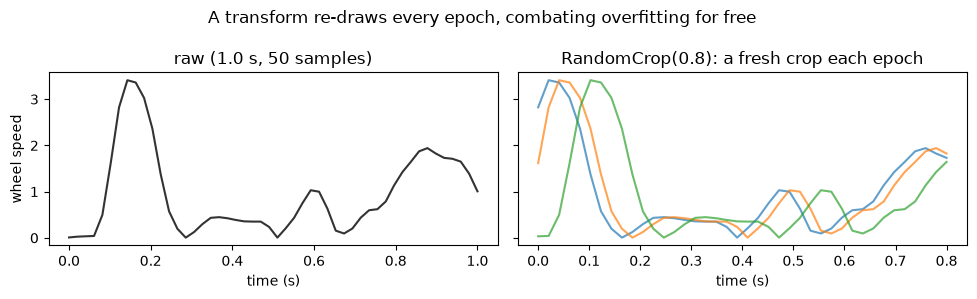

In [27]:
augment = Compose([RandomCrop(0.8)])
base = demo_rec.slice(DEMO_T0, DEMO_T0 + 1.0)
y_base = np.asarray(base.wheel.speed)

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
axes[0].plot(np.linspace(0, 1.0, len(y_base)), y_base, color="#333333")
axes[0].set_title(f"raw (1.0 s, {len(y_base)} samples)")
for _ in range(3):
    a = augment(demo_rec.slice(DEMO_T0, DEMO_T0 + 1.0))
    y_a = np.asarray(a.wheel.speed)
    axes[1].plot(np.linspace(0, len(y_a) / 50.0, len(y_a)), y_a, alpha=0.7)
axes[1].set_title("RandomCrop(0.8): a fresh crop each epoch")
for ax in axes:
    ax.set_xlabel("time (s)")
axes[0].set_ylabel("wheel speed")
fig.suptitle("A transform re-draws every epoch, combating overfitting for free")
plt.tight_layout()
plt.show()

## 5. Mask or select units

Units are a labelled axis, so you can drop or select them declaratively.
`UnitDropout` keeps a random subset each sample (augmentation / regularizer);
`UnitFilter` keeps a fixed subset, e.g. one brain region, turning "which region
drives wheel decoding?" into a one-line ablation.

UnitDropout: 1547 -> 60 units kept
UnitDropout: 1547 -> 170 units kept
UnitDropout: 1547 -> 93 units kept
UnitDropout: 1547 -> 32 units kept
UnitDropout: 1547 -> 263 units kept


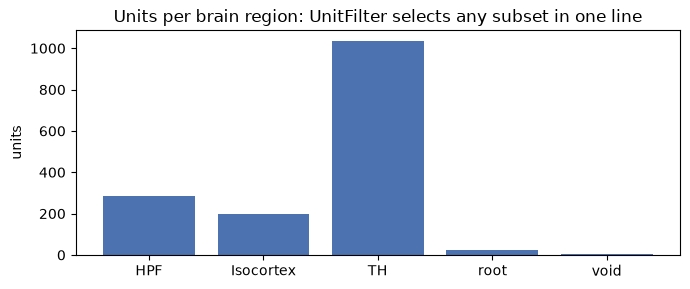

UnitFilter to thalamus: 1547 -> 1035 units


In [28]:
# (a) UnitDropout: a different random subset of units each call
for _ in range(5):
    before = len(demo_rec.slice(DEMO_T0, DEMO_T0 + 1.0).units)
    after = len(
        UnitDropout(field="spikes")(demo_rec.slice(DEMO_T0, DEMO_T0 + 1.0)).units
    )
    print(f"UnitDropout: {before} -> {after} units kept")

# (b) UnitFilter: keep only units in one brain region (cosmos atlas)
regions = np.asarray(demo_rec.units.region_cosmos)
labels, counts = np.unique(regions, return_counts=True)
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar([r.decode() for r in labels], counts, color="#4C72B0")
ax.set_ylabel("units")
ax.set_title("Units per brain region: UnitFilter selects any subset in one line")
plt.tight_layout()
plt.show()

th_filter = UnitFilter(
    mask_fn=lambda u: np.asarray(u.region_cosmos) == b"TH", field="spikes"
)
n_before = len(demo_rec.slice(DEMO_T0, DEMO_T0 + 1.0).units)
n_after = len(th_filter(demo_rec.slice(DEMO_T0, DEMO_T0 + 1.0)).units)
print(f"UnitFilter to thalamus: {n_before} -> {n_after} units")

## 6. Sampling window with jitter

`TrialSampler` emits the same fixed windows every epoch (reproducible eval).
`RandomFixedWindowSampler` applies a fresh random temporal jitter each epoch, so
the model sees slightly shifted positions within every interval: more effective
data, less positional overfitting. Only the sampler changes.

In [29]:
jitter_sampler = RandomFixedWindowSampler(
    sampling_intervals={RECORDING_ID: demo_iv}, window_length=1.0
)
fixed_sampler = TrialSampler(sampling_intervals={RECORDING_ID: demo_iv})


def first_starts(sampler, n=6):
    return [round(float(idx.start), 2) for idx in list(sampler)[:n]]


print("RandomFixedWindowSampler (jitter, new positions each epoch):")
print("  epoch 1:", first_starts(jitter_sampler))
print("  epoch 2:", first_starts(jitter_sampler))
print("TrialSampler (fixed windows, identical each epoch):")
print("  epoch 1:", first_starts(fixed_sampler))
print("  epoch 2:", first_starts(fixed_sampler))

RandomFixedWindowSampler (jitter, new positions each epoch):
  epoch 1: [537.04, 425.97, 271.84, 340.48, 87.25, 678.34]
  epoch 2: [801.13, 645.96, 150.14, 747.99, 83.68, 608.04]
TrialSampler (fixed windows, identical each epoch):
  epoch 1: [45.57, 48.69, 56.48, 61.76, 65.9, 69.09]
  epoch 2: [45.57, 48.69, 56.48, 61.76, 65.9, 69.09]
